**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 3 - Exercício 4**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.7109, -0.1537, -0.8738, -0.4803, -0.2441,  1.1231, -0.7382, -0.0923,
         -0.2572,  0.8467]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

**Exercício 1 — impressão ao final de cada mini-batch**

O laço de treinamento abaixo foi modificado para imprimir, ao final dos mini-batches, uma linha no formato solicitado (`Época: 1/5, batch: 100`). Como o número de mini-batches por época é elevado (480 para `batch_size=100`), a impressão é realizada a cada `print_every` mini-batches — e também no último mini-batch de cada época —, de modo a acompanhar o progresso sem gerar uma saída excessivamente extensa. A impressão de resumo ao final de cada época foi preservada.

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

# Exercício 1: define a cada quantos mini-batches será impresso o progresso
print_every = 100

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # ------------------------------------------------------------
        # Exercício 1: print ao final de cada mini-batch
        # Estilo solicitado: 'Época: 1/4, batch: 600'
        # A impressão é feita a cada 'print_every' mini-batches para não
        # poluir a saída, e também no último mini-batch da época.
        # ------------------------------------------------------------
        if (i + 1) % print_every == 0 or (i + 1) == len(loader_train):
            print(f'Época: {epoch+1}/{n_epochs}, batch: {i+1}, loss: {loss.item():.4f}')

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    # print ao final de cada época (mantido do notebook original)
    print(f'--- Fim da Época [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f} ---')

Época: 1/5, batch: 100, loss: 0.5320
Época: 1/5, batch: 200, loss: 0.3295
Época: 1/5, batch: 300, loss: 0.2912
Época: 1/5, batch: 400, loss: 0.3107
Época: 1/5, batch: 480, loss: 0.3949
--- Fim da Época [1/5], Train Loss: 0.4060, Train Acc: 0.8844, Val Loss: 0.3259, Val Acc: 0.9087 ---
Época: 2/5, batch: 100, loss: 0.2901
Época: 2/5, batch: 200, loss: 0.3688
Época: 2/5, batch: 300, loss: 0.1899
Época: 2/5, batch: 400, loss: 0.3052
Época: 2/5, batch: 480, loss: 0.4205
--- Fim da Época [2/5], Train Loss: 0.3113, Train Acc: 0.9119, Val Loss: 0.3055, Val Acc: 0.9157 ---
Época: 3/5, batch: 100, loss: 0.3547
Época: 3/5, batch: 200, loss: 0.3232
Época: 3/5, batch: 300, loss: 0.4305
Época: 3/5, batch: 400, loss: 0.2789
Época: 3/5, batch: 480, loss: 0.2313
--- Fim da Época [3/5], Train Loss: 0.2955, Train Acc: 0.9164, Val Loss: 0.3048, Val Acc: 0.9149 ---
Época: 4/5, batch: 100, loss: 0.1369
Época: 4/5, batch: 200, loss: 0.3500
Época: 4/5, batch: 300, loss: 0.2632
Época: 4/5, batch: 400, loss: 0

In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2811
Última acurácia de treinamento: 0.9209
Última perda de validação: 0.2950
Última acurácia de validação: 0.9179


### Visualizando a evolução da perda e acurácia

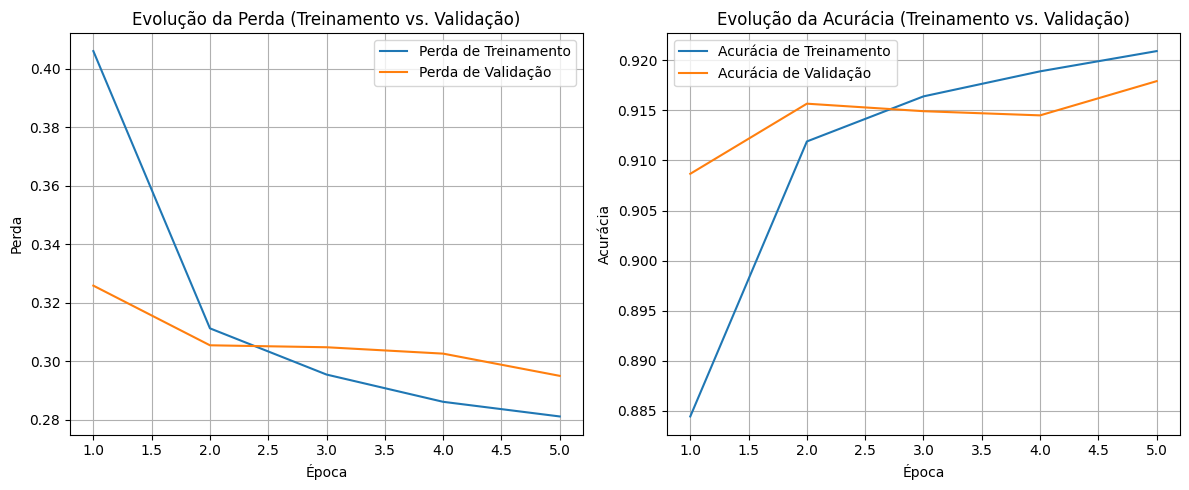

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
2. Em uma época, quantos mini-batches existem?
3. Qual é a definição de época?

### Respostas

**1. Qual é o tamanho do mini-batch?**

O tamanho do mini-batch é definido pela variável `batch_size`, fixada em **100** neste notebook. Isso significa que, a cada passo de otimização, o gradiente é calculado a partir de um subconjunto de 100 amostras.

**2. Em uma época, quantos mini-batches existem?**

O conjunto de treinamento corresponde a 80% das 60.000 amostras do MNIST, totalizando **48.000 amostras**. Com mini-batches de 100 elementos, o número de mini-batches por época é $48000 / 100 = \textbf{480}$. (De modo geral, o número de mini-batches é $\lceil N / \text{batch\_size} \rceil$, onde $N$ é o número de amostras de treinamento; quando $N$ é divisível pelo tamanho do batch, a divisão é exata.) Esse valor pode ser obtido diretamente por `len(loader_train)`.

**3. Qual é a definição de época?**

Uma **época** corresponde a uma passagem completa do algoritmo de treinamento por todas as amostras do conjunto de treinamento. No gradiente descendente estocástico por mini-batches, uma época é concluída quando todos os mini-batches foram processados uma vez — ou seja, quando o modelo já "viu" cada amostra exatamente uma vez. Como o treinamento normalmente requer múltiplas passagens para convergir, executam-se várias épocas (neste notebook, `n_epochs = 5`).

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

### Exercício 2 — comparação da queda da perda para diferentes tamanhos de mini-batch

Para comparar de forma sistemática o efeito do tamanho do mini-batch, o procedimento de treinamento é encapsulado em uma função `treinar_e_coletar_perdas`, que recebe o `batch_size` como parâmetro e retorna a perda registrada ao final de cada mini-batch, juntamente com a posição correspondente em "época fracionária". Em seguida, o treinamento é executado para diversos valores de `batch_size`, e as curvas de perda são sobrepostas em um único gráfico.

Para todos os experimentos, fixa-se a mesma semente aleatória, de modo que as diferenças observadas decorram exclusivamente do tamanho do mini-batch, e não da inicialização ou da ordem de embaralhamento dos dados.

In [11]:
def treinar_e_coletar_perdas(batch_size, n_epochs=5, lr=0.5, seed=1234):
    """Treina o modelo para um dado batch_size e retorna as perdas por mini-batch."""
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)

    # mesma divisão treino/validação para todos os experimentos
    ds_tr, ds_v = torch.utils.data.random_split(
        full_train_dataset, [train_size, val_size], generator=gen)
    loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)

    m = torch.nn.Linear(28 * 28, 10)
    crit = torch.nn.CrossEntropyLoss()
    opt = torch.optim.SGD(m.parameters(), lr=lr)

    batch_losses = []
    epoch_fracs = []
    n_batches = len(loader)

    for epoch in range(n_epochs):
        m.train()
        for i, (xb, yb) in enumerate(loader):
            out = m(xb.view(-1, 28 * 28))
            loss = crit(out, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            batch_losses.append(loss.item())
            # posição em época fracionária (ex.: metade da 1a época = 0.5)
            epoch_fracs.append(epoch + (i + 1) / n_batches)

    return epoch_fracs, batch_losses, n_batches

In [12]:
# Função auxiliar: média móvel para suavizar a curva de perda (reduz o ruído do SGD)
def media_movel(valores, janela):
    valores = np.array(valores)
    if len(valores) < janela:
        return valores
    kernel = np.ones(janela) / janela
    return np.convolve(valores, kernel, mode='valid')

# Tamanhos de mini-batch a comparar
batch_sizes_teste = [10, 50, 100, 500]

resultados = {}
for bs in batch_sizes_teste:
    fracs, blosses, n_b = treinar_e_coletar_perdas(bs)
    resultados[bs] = (fracs, blosses, n_b)
    print(f'batch_size={bs}: {n_b} mini-batches/época, perda final={blosses[-1]:.4f}')

batch_size=10: 4800 mini-batches/época, perda final=0.4580
batch_size=50: 960 mini-batches/época, perda final=0.1278
batch_size=100: 480 mini-batches/época, perda final=0.1619
batch_size=500: 96 mini-batches/época, perda final=0.3910


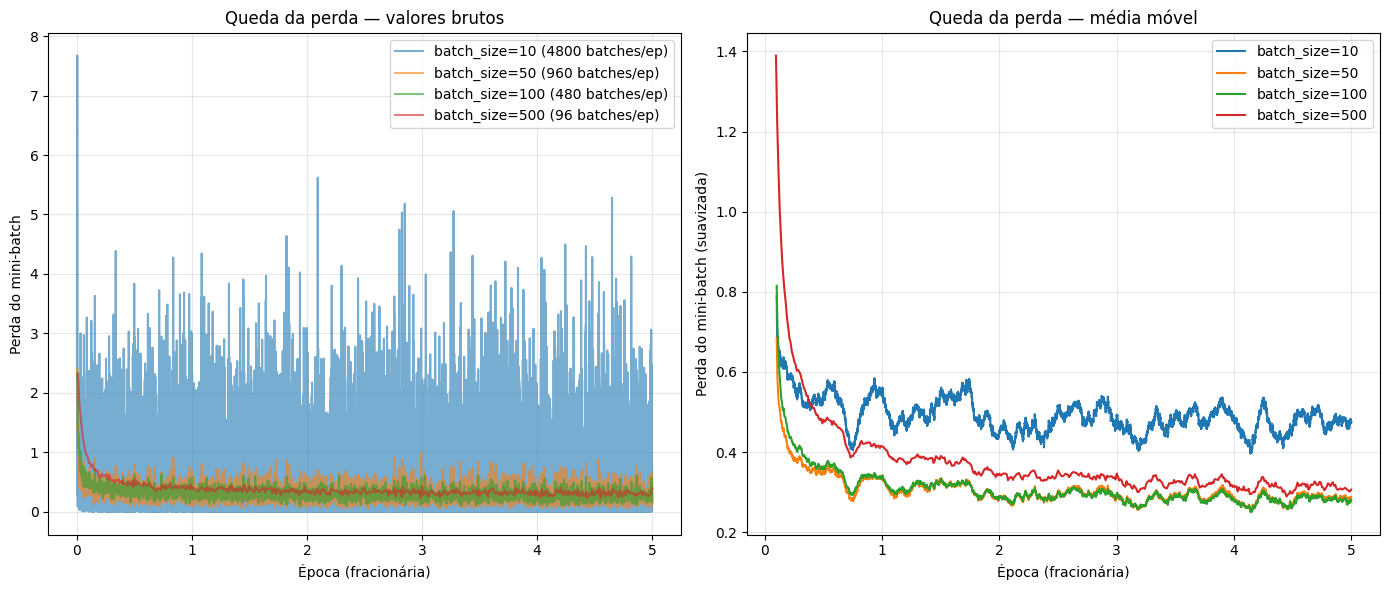

In [13]:
plt.figure(figsize=(14, 6))

# Gráfico 1: curva crua (mostra o ruído característico do SGD)
plt.subplot(1, 2, 1)
for bs in batch_sizes_teste:
    fracs, blosses, n_b = resultados[bs]
    plt.plot(fracs, blosses, alpha=0.6, label=f'batch_size={bs} ({n_b} batches/ep)')
plt.xlabel('Época (fracionária)')
plt.ylabel('Perda do mini-batch')
plt.title('Queda da perda — valores brutos')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: curva suavizada por média móvel (facilita a comparação da tendência)
plt.subplot(1, 2, 2)
for bs in batch_sizes_teste:
    fracs, blosses, n_b = resultados[bs]
    janela = max(1, len(blosses) // 50)
    blosses_suave = media_movel(blosses, janela)
    fracs_suave = fracs[len(fracs) - len(blosses_suave):]
    plt.plot(fracs_suave, blosses_suave, label=f'batch_size={bs}')
plt.xlabel('Época (fracionária)')
plt.ylabel('Perda do mini-batch (suavizada)')
plt.title('Queda da perda — média móvel')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Análise dos resultados**

A comparação evidencia o compromisso (*trade-off*) característico do tamanho do mini-batch no gradiente descendente estocástico:

- **Mini-batches pequenos** (por exemplo, `batch_size=10`) produzem um número muito maior de atualizações por época (4.800 atualizações), o que tende a acelerar a redução inicial da perda quando medida em função do número de épocas. Em contrapartida, cada atualização baseia-se em poucas amostras, resultando em estimativas ruidosas do gradiente — daí a elevada variância observada na curva bruta de perda.

- **Mini-batches grandes** (por exemplo, `batch_size=500`) produzem poucas atualizações por época (96 atualizações), com gradientes mais estáveis e curvas mais suaves, porém com redução mais lenta da perda ao longo das épocas, justamente por realizarem menos passos de otimização no mesmo intervalo.

Os gráficos apresentam a perda em duas formas: os valores brutos, que tornam visível o ruído do SGD (mais acentuado para batches pequenos), e uma versão suavizada por média móvel, que facilita a comparação da tendência geral de queda entre as configurações. Observa-se que tamanhos intermediários de mini-batch (50 e 100) oferecem um bom equilíbrio entre velocidade de convergência e estabilidade.

## Conclusões sobre os experimentos deste notebook


## Considerações finais

Este notebook explorou o **gradiente descendente estocástico por mini-batches** aplicado à classificação de dígitos do MNIST, empregando as classes `Dataset` e `DataLoader` do PyTorch.

Quanto às perguntas conceituais, identificou-se que o tamanho do mini-batch é 100, que há 480 mini-batches por época (48.000 amostras de treinamento divididas em grupos de 100) e que uma época corresponde a uma passagem completa por todas as amostras de treinamento.

No primeiro exercício, o laço de treinamento foi instrumentado para reportar o progresso ao final dos mini-batches, no formato `Época: e/E, batch: b`, permitindo um acompanhamento mais granular do treinamento do que o resumo por época.

No segundo exercício, a comparação sistemática de diferentes tamanhos de mini-batch tornou evidente o compromisso entre **velocidade de convergência** e **estabilidade do gradiente**: batches menores realizam mais atualizações, porém mais ruidosas, ao passo que batches maiores produzem trajetórias de perda mais suaves, mas com menos passos de otimização por época. Esse compromisso é uma das decisões de projeto mais relevantes no treinamento de redes neurais, influenciando diretamente o tempo de treinamento, o uso de memória e a qualidade da convergência.